# Getting started: topological machine learning for SMLM data

This notebook walks through the three-view architecture behind the accompanying paper end to end, on a small public dataset: load real localization data, compute persistence diagrams, and ask each of the three views (scalar, functional, metric) the same question — does a topological signature separate two groups of nuclei at all?

The dataset here is **not** the paper's own data (see `../data/README.md`). It's the public sample set accompanying J. Weidner, C. Neitzel, M. Gote, J. Deck, K. A. Küntzelmann, G. Pilarczyk, M. Falk, and M. Hausmann, "Advanced image-free analysis of the nano-organization of chromatin and other biomolecules by single molecule localization microscopy (SMLM)," *Computational and Structural Biotechnology Journal*, 21:2018–2034, 2023, doi:10.1016/j.csbj.2023.03.009 — repository: https://github.com/jonasw247/TDA_applied_on_SMLM — used with thanks, under the same GPLv3 license as this repository. 21 "cancer cell" nuclei and 21 "skin cell" nuclei, one marker, one snapshot each.

This dataset has no DBSCAN cluster labels, no repair timecourse, and no co-staining, so this notebook only shows **Scale C** (the whole localization point cloud) at **Tier 1** (existence — is a difference detectable at all). The library implements substantially more than that: Scales A and B, and Tiers 2 through 5 (robustness, temporal structure, trajectories, within-nucleus coupling). Those need data this demo set doesn't have; see `src/tml_smlm/` and each module's own docstring for the full, worked versions.

Running this notebook top to bottom takes several minutes on a laptop — almost all of it is real persistent-homology computation on real point clouds (`ripser`) and permutation testing, not this repository's own overhead. The slowest two cells are marked below with their measured runtime.

## Load data

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from tml_smlm.io.demo_loader import load_demo_dataset, demo_manifest

DATA_ROOT = Path("../data/weidner_sample")
nuclei = load_demo_dataset(DATA_ROOT)
print(f"Loaded {len(nuclei)} nuclei")

manifest = demo_manifest(nuclei)
manifest.groupby("cell_type")["n_localisations"].describe()[["count", "mean", "std", "min", "max"]]

Loaded 42 nuclei


           count         mean          std     min     max
cell_type                                                 
cancer      21.0  1189.047619   458.903092   191.0  2006.0
normal      21.0  2896.571429  1434.327144  1499.0  7233.0

The two groups differ a fair amount in raw localization count already (see the table above). That's worth keeping in mind for everything that follows: a real topological difference and a difference that's just "one group has more points" can look similar in a raw comparison. The full pipeline (`src/tml_smlm/diagnostics/size_confound_audit.py`, and the residualization built into `view1_scalar/classification.py`) treats this seriously; this notebook, scoped to Tier 1 only, does not residualize against it, so the Tier-1 results below should be read as "a difference exists," not yet as "a difference exists independent of how many localizations each group has."

## Persistent homology

In [2]:
from tml_smlm.features.persistence_features import scale_c_features
import time

t0 = time.time()
feats_rows, dgms_h0, dgms_h1 = [], [], []
for n in nuclei:
    feats, dgms = scale_c_features(n)
    feats_rows.append({"cell_type": n.cell_type, "replicate": n.replicate,
                        "n_localisations": n.n_localisations, **feats})
    dgms_h0.append(dgms["scaleC_h0"])
    dgms_h1.append(dgms["scaleC_h1"])

df = pd.DataFrame(feats_rows)
y = (df["cell_type"] == "cancer").astype(int).to_numpy()
print(f"Computed {len(df)} diagrams in {time.time()-t0:.0f}s")

Computed 42 diagrams in 101s


*(measured: ~100s on the machine this notebook was last run on — one real `ripser` call per nucleus, no shortcuts)*

Take a look at a persistence diagram: one nucleus's H0 (components, circles) and H1 (loops, triangles) birth-death pairs, against the diagonal where a feature would have zero lifetime.

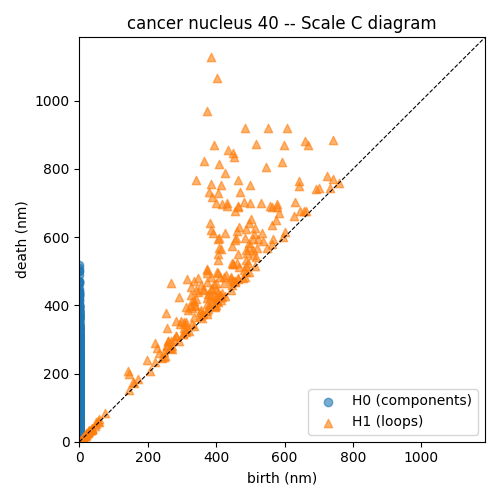

In [3]:
example = 0
h0, h1 = dgms_h0[example], dgms_h1[example]

# Every H0 diagram carries exactly one infinite-persistence bar (the single
# connected-component class that never merges away) -- see the correctness
# note in features/persistence_features.py. It has nowhere finite to sit on
# this plot, so it's excluded here the same way `_clean()` excludes it before
# any landscape computation.
h0_finite = h0[np.isfinite(h0[:, 1])]

fig, ax = plt.subplots(figsize=(5, 5))
for dgm, marker, label in [(h0_finite, "o", "H0 (components)"), (h1, "^", "H1 (loops)")]:
    if len(dgm):
        ax.scatter(dgm[:, 0], dgm[:, 1], marker=marker, alpha=0.6, label=label)
top = max(h0_finite[:, 1].max() if len(h0_finite) else 1.0,
          h1[:, 1].max() if len(h1) else 1.0)
lims = [0, top * 1.05]
ax.plot(lims, lims, "k--", linewidth=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("birth (nm)"); ax.set_ylabel("death (nm)")
ax.set_title(f"{nuclei[example].cell_type} nucleus {nuclei[example].replicate} — Scale C diagram")
ax.legend()
plt.tight_layout()
plt.show()

## View 1 — scalar / distributional

Reduce each diagram to finite summary statistics (Betti-curve mean/variance, persistent entropy, landscape integral and peak location, for both H0 and H1) and ask the most direct question: can a classifier tell the two groups apart from these ten numbers alone? This uses the real library functions (`cv_balanced_accuracy`, `permutation_test` from `view1_scalar/classification.py`), not a notebook-only reimplementation — the same code the paper's own Tier-1 tests are built on.

The permutation count below (100) is deliberately smaller than the paper's own (1,000–10,000), purely so this cell finishes in about two minutes instead of twenty. `permutation_test`'s own `n_permutations` argument is where that trade-off lives; turn it up if you have the time.

In [4]:
from tml_smlm.view1_scalar.classification import cv_balanced_accuracy, permutation_test

feature_cols = [c for c in df.columns if c.startswith("scaleC_")]
X = df[feature_cols]

scores = cv_balanced_accuracy(X, y, impute=False)
print(f"View 1 Tier 1 — cross-validated balanced accuracy: {scores.mean():.3f} (sd {scores.std():.3f})")

t0 = time.time()
strata = np.zeros(len(y), dtype=int)  # no timepoints in this dataset to stratify by
perm = permutation_test(X, y, observed_ba=float(scores.mean()), n_permutations=100,
                         impute=False, resid_col=None, strata=strata, rng_seed=0, n_jobs=1)
print(f"permutation p-value: {perm['p_value']:.4f}  (null mean {perm['perm_mean_ba']:.3f}, {time.time()-t0:.0f}s)")

View 1 Tier 1 — cross-validated balanced accuracy: 0.907 (sd 0.107)
permutation p-value: 0.0000  (null mean 0.520, 114s)


A balanced accuracy well above chance, and a null distribution centered near 0.5 that the observed score clears entirely: at Tier 1, View 1's scalar summary of the Scale C diagram separates this dataset's two groups cleanly.

## View 2 — functional / localization

Treat the diagram as a function (the persistence landscape) and ask a sharper question than View 1: not just whether a difference exists, but *where along the birth-radius axis* it concentrates, via a sparse fused-lasso fit. Again, this calls the real library code (`vectorise`, `fl_cv` from `view2_functional/localization.py`) on the H1 diagrams computed above.

In [5]:
from tml_smlm.view2_functional.localization import vectorise, fl_cv

L, grid = vectorise(dgms_h1, k=1)
fl_result = fl_cv(L, y)
print(f"View 2 Tier 1 — fused-lasso CV balanced accuracy at lambda_1se: {fl_result['ba_at_lam_1se']:.3f}")
print(f"nonzero coefficients at lambda_1se: {fl_result['n_nonzero_1se']} of {L.shape[1]}")

View 2 Tier 1 — fused-lasso CV balanced accuracy at lambda_1se: 0.500
nonzero coefficients at lambda_1se: 0 of 300


This comes back null: chance-level accuracy, zero nonzero coefficients. Worth sitting with rather than explaining away. View 2 is asking a harder question than View 1 — not "is there a difference" but "is there a difference concentrated at a specific, identifiable position" — and with 42 nuclei split across cross-validation folds and a 300-point grid, there may simply not be enough data here to localize anything with confidence, even though View 1 found a real aggregate difference in the same diagrams. In the paper's own archives (500-1,700 nuclei per stratum), the equivalent test does resolve a real, seed-stable position — see `view2_functional/robustness.py` and `view2_functional/temporal_trajectory.py` for the fully worked version. A null result here is a property of this small demo, not evidence that View 2 doesn't work.

## View 3 — metric / geometric

Treat each diagram as a single point in a metric space (2-Wasserstein distance) and ask whether the two groups differ as whole geometric objects — via each group's Fréchet mean/variance and a permutation test on the medoid-to-medoid distance between groups. Real library code again: `pairwise_distance_matrix`, `frechet_mean`, `frechet_variance`, `permutation_group_test_wasserstein` from `utils/wasserstein_geometry.py`.

In [6]:
from tml_smlm.utils.wasserstein_geometry import (
    pairwise_distance_matrix, frechet_mean, frechet_variance, permutation_group_test_wasserstein,
)

t0 = time.time()
D = pairwise_distance_matrix(dgms_h1)
labels = df["cell_type"].to_numpy()

cancer_dgms = [d for d, c in zip(dgms_h1, labels) if c == "cancer"]
normal_dgms = [d for d, c in zip(dgms_h1, labels) if c == "normal"]
mean_cancer, _ = frechet_mean(cancer_dgms)
mean_normal, _ = frechet_mean(normal_dgms)
var_cancer = frechet_variance(cancer_dgms, mean_cancer)
var_normal = frechet_variance(normal_dgms, mean_normal)

result = permutation_group_test_wasserstein(D, labels, "cancer", "normal", n_permutations=1000, rng_seed=0)
print(f"View 3 Tier 1 — medoid-distance permutation test: observed {result['observed']:.1f}, "
      f"null mean {result['null_mean']:.1f} (sd {result['null_sd']:.1f}), p = {result['p_value']:.4f}  ({time.time()-t0:.0f}s)")
print(f"Frechet variance — cancer: {var_cancer:.0f}, normal: {var_normal:.0f}")

View 3 Tier 1 — medoid-distance permutation test: observed 1417.7, null mean 648.3 (sd 131.2), p = 0.0000  (36s)
Frechet variance — cancer: 320711, normal: 498759


Both groups' medoid diagrams sit further apart than any relabeling in the permutation null ever produces, and the two groups' Fréchet variances differ too — the "normal" group's diagrams are noticeably more internally variable than the "cancer" group's. Like View 1, View 3 finds a clear existence-level signal in this dataset; unlike View 1, it also says something about internal group homogeneity that a scalar summary alone doesn't.

## What isn't shown here

This notebook stayed at Scale C, Tier 1, for all three views, because that's what a single-marker, single-timepoint, non-co-stained public dataset can support. The library implements substantially more, runnable once the right kind of data is available:

| Capability | Needs | Module |
|---|---|---|
| Scale A / B (per-focus, per-cluster structure) | DBSCAN cluster labels | `features/persistence_features.py` |
| Tier 2 (robustness to a count confound) | enough samples to residualize with confidence | `view1_scalar/robustness.py`, `view2_functional/robustness.py`, `diagnostics/size_confound_audit.py` |
| Tier 3 (does the signal change over time) | multiple real timepoints | `view1_scalar/temporal_structure.py`, `view2_functional/temporal_trajectory.py` |
| Tier 4 (trajectory against a matched control, or against another marker) | a matched control per timepoint | `view3_metric/population_geometry.py`, `view3_metric/multiple_comparisons.py` |
| Tier 5 (within-nucleus coupling between two markers) | verified co-staining | `view3_metric/coupling.py`, `view2_functional/coupling.py` |

`src/tml_smlm/io/kip_archive_loader.py` is the loader that was actually used to produce the paper's own results, included for transparency; it won't run against this notebook's demo data (different archive, different file layout), only against the datasets it was written for.

---

*J. Weidner, C. Neitzel, M. Gote, J. Deck, K. A. Küntzelmann, G. Pilarczyk, M. Falk, and M. Hausmann. Advanced image-free analysis of the nano-organization of chromatin and other biomolecules by single molecule localization microscopy (SMLM). Computational and Structural Biotechnology Journal, 21:2018–2034, 2023. doi:10.1016/j.csbj.2023.03.009. Repository: https://github.com/jonasw247/TDA_applied_on_SMLM*